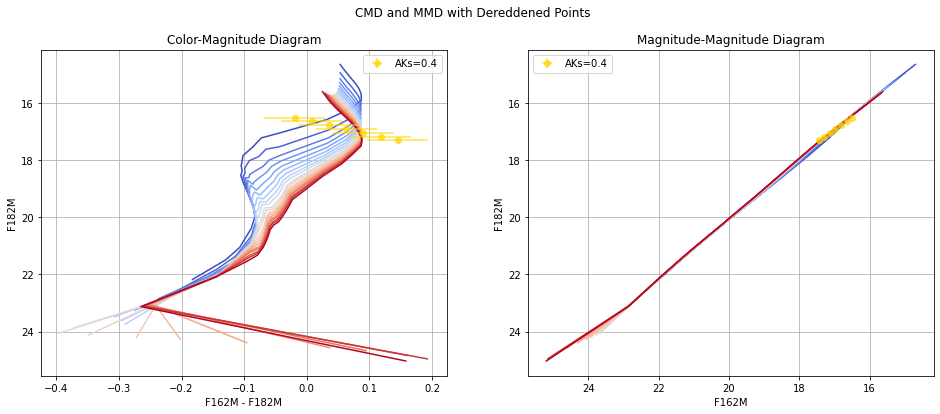

In [26]:
import os
import numpy as np
import matplotlib.pyplot as plt
from spisea import synthetic, evolution, atmospheres, reddening
import csv

# Paths for isochrones and output
iso_dir = 'isochrones/'
output_dir = 'output_diagrams/'
os.makedirs(output_dir, exist_ok=True)

# Estimation variables
star_index = 0  # Set which star in the CSV to analyze

# Define static isochrone parameters
dist = 4500  # Distance in parsecs
evo_model = evolution.Baraffe15()
atm_func = atmospheres.get_merged_atmosphere
red_law = reddening.RedLawCardelli(3.1)
filt_list = ['jwst,F162M', 'jwst,F182M']
filters = ['m_jwst_F162M', 'm_jwst_F182M']
metallicity = 0
level_ages = np.linspace(1, 10, 19) * 1e6  # Define age array
log_age_arr = np.log10(level_ages)

# Load sample magnitudes and errors from CSV
sample_mags = []
sample_errs = []
with open('../s284.csv', mode='r') as file:
    csvFile = csv.reader(file)
    next(csvFile)  # Skip header row
    for lines in csvFile:
        mags = [float(lines[i]) for i in range(1, len(lines), 2)]
        errs = [float(lines[i]) for i in range(2, len(lines), 2)]
        sample_mags.append(mags)
        sample_errs.append(errs)

# Function to generate isochrone grid
def generate_isochrones(AKs):
    return np.array([
        synthetic.IsochronePhot(log_age, AKs, dist, metallicity=metallicity,
                                evo_model=evo_model, atm_func=atm_func,
                                red_law=red_law, filters=filt_list,
                                iso_dir=iso_dir)
        for log_age in log_age_arr
    ])

# Generate isochrone grid for AKs = 0 (no extinction)
isochrone_AKs_00 = generate_isochrones(0.0)

# Wavelength dictionary for JWST filters
filter_wavelengths = {
    "m_jwst_F162M": 1.62,
    "m_jwst_F182M": 1.82,
    "m_jwst_F200W": 2.00,
    "m_jwst_F356M": 3.56,
    "m_jwst_F405N": 4.05
}

# Extract magnitudes and errors for the selected star
m162, m182 = sample_mags[star_index][:2]  # Magnitudes
err162, err182 = sample_errs[star_index][:2]  # Errors

# Define AKs range for dereddening
AKs_values = np.arange(0.4, 1.1, 0.1)  # Adjustable range and step size

# Store dereddened magnitudes
dereddened_mags = []
for AKs_ref in AKs_values:
    m162_dered = m162 - red_law.Cardelli89(filter_wavelengths["m_jwst_F162M"], AKs_ref)
    m182_dered = m182 - red_law.Cardelli89(filter_wavelengths["m_jwst_F182M"], AKs_ref)
    dereddened_mags.append((m162_dered, m182_dered))

# Compute errors in color (m162 - m182) and in F182M magnitude
color_err = np.sqrt(err162**2 + err182**2)  # Propagate errors in color
mag_err = err182  # Vertical error is just the F182M error

# Plot function with dereddened points
def plot_cmd_mmd_with_dereddening(isochrone_grid, dered_mags, ref_errs, title, filename):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    cmap = plt.get_cmap("coolwarm")

    # Plot Color-Magnitude Diagram (CMD)
    for i, instance in enumerate(isochrone_grid):
        color = cmap(i / (len(isochrone_grid) - 1))
        ax1.plot(instance.points["m_jwst_F162M"] - instance.points["m_jwst_F182M"],
                 instance.points["m_jwst_F182M"], color=color)
    
    for i, (m162_d, m182_d) in enumerate(dered_mags):
        ax1.errorbar(m162_d - m182_d, m182_d, xerr=ref_errs[0], yerr=ref_errs[1],
                     fmt='o', color='gold', alpha=0.7, label=f"AKs={AKs_values[i]:.1f}" if i == 0 else "")
    
    ax1.set_xlabel("F162M - F182M")
    ax1.set_ylabel("F182M")
    ax1.invert_yaxis()
    ax1.grid(True)
    ax1.legend()
    ax1.set_title("Color-Magnitude Diagram")

    # Plot Magnitude-Magnitude Diagram (MMD)
    for i, instance in enumerate(isochrone_grid):
        color = cmap(i / (len(isochrone_grid) - 1))
        ax2.plot(instance.points["m_jwst_F162M"], instance.points["m_jwst_F182M"], color=color)
    
    for i, (m162_d, m182_d) in enumerate(dered_mags):
        ax2.errorbar(m162_d, m182_d, xerr=ref_errs[0], yerr=ref_errs[1],
                     fmt='o', color='gold', alpha=0.7, label=f"AKs={AKs_values[i]:.1f}" if i == 0 else "")
    
    ax2.set_xlabel("F162M")
    ax2.set_ylabel("F182M")
    ax2.invert_xaxis()
    ax2.invert_yaxis()
    ax2.grid(True)
    ax2.legend()
    ax2.set_title("Magnitude-Magnitude Diagram")

    plt.suptitle(title)
    # plt.savefig(os.path.join(output_dir, filename))
    plt.show()

# Plot CMD and MMD with dereddened points
plot_cmd_mmd_with_dereddening(isochrone_AKs_00, dereddened_mags, [color_err, mag_err],
                              "CMD and MMD with Dereddened Points", "CMD_MMD_DEREDDENED.png")


In [32]:
# Define degrees of freedom (DOF) as number of filters used minus 1
DOF = len(filt_list) - 1  

# Storage for chi-squared values
chi_squared_results = []

for AKs_ref in AKs_values:
    # Generate isochrones for the given AKs
    isochrone_grid = generate_isochrones(AKs_ref)

    # Compute dereddened magnitudes
    m162_dered = m162 - red_law.Cardelli89(filter_wavelengths["m_jwst_F162M"], AKs_ref)
    m182_dered = m182 - red_law.Cardelli89(filter_wavelengths["m_jwst_F182M"], AKs_ref)

    # Compute chi-squared values
    chi_squared_grid = chi_square_with_errors(isochrone_grid, [m162_dered, m182_dered], [err162, err182])
    
    # Compute reduced chi-square
    reduced_chi_squared = chi_squared_grid / DOF  
    chi_squared_results.append((AKs_ref, reduced_chi_squared))

# Now you can plot heatmaps for each AKs value
def plot_chi_squared_heatmaps(chi_squared_results, log_age_arr):
    fig, axes = plt.subplots(1, len(chi_squared_results), figsize=(5 * len(chi_squared_results), 5))
    
    if len(chi_squared_results) == 1:
        axes = [axes]  # Ensure we can iterate even for one plot
    
    for ax, (AKs_val, chi_sq_grid) in zip(axes, chi_squared_results):
        im = ax.imshow(chi_sq_grid, aspect="auto", cmap="viridis", origin="lower",
                       extent=[0, chi_sq_grid.shape[1], log_age_arr.min(), log_age_arr.max()])
        ax.set_title(f"AKs = {AKs_val:.1f}")
        ax.set_xlabel("Isochrone Index")
        ax.set_ylabel("Log Age")
        fig.colorbar(im, ax=ax, label="Reduced Chi-Squared")
    
    plt.tight_layout()
    plt.show()

# Plot the chi-squared heatmaps
plot_chi_squared_heatmaps(chi_squared_results, log_age_arr)

Isochrone generation took 1.192459 s.
Making photometry for isochrone: log(t) = 6.00  AKs = 0.22  dist = 4500
     Starting at:  2025-03-11 01:29:43.150024   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F162M = 22.35
Starting filter: jwst,F182M   Elapsed time: 0.61 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F182M = 22.47
      Time taken: 1.25 seconds
Isochrone generation took 1.161268 s.
Making photometry for isochrone: log(t) = 6.18  AKs = 0.22  dist = 4500
     Starting at:  2025-03-11 01:29:45.571343   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2292 K  m_jwst_F162M = 22.71
Starting filter: jwst,F182M   Elapsed time: 0.61 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2292 K  m_jwst_F182M = 22.86


KeyboardInterrupt: 